# **Case Study1:  Analyzing World GDP Data**
### **Prepared by**: Dr. Hum Nath Bhandari, Department of Mathematics, RWU

### **Course**: MATH 355/COMSC 415-Machine Learning 


### **Your Name**: 


###  **Overview**

In this case study, you are going to perform data preporocessing steps on the **World GDP** data.  This is a publicly available data, provided and maintained by **The World Bank**. You can find the original data from the website of the Bank. However, one version of the data set, called **GDP.csv** is available on Bridges.

### **Learning Expections**

Here are the following expections from this case study:

- Setting up python data analysis enviornment.
- Getting data from files.
- Inspecting the data set to get basic information.
- Extracting basic statistical summary.
- Cleaning the data set and handling the missing values (if any).
- Creating the tidy data for visualization.
- Visualizing the dataset.

### Instructions:

Please solve the following questions to fullfill the desired learning objectives.



**Question 1**. Import the necessary Python libraries and answer the following questions.

- Read the **GDP.csv** data file. You can import only few  columns. Use the keyword **usecols = ['Country Name', 'Country Code', 'Year', 'Value']**  inside **read_csv** function.

- How many observations are there in the data? What are the row and column indices?



There are 4 columns of data including the country name, country code, year, and value. And there are 11510 entries into the csv.

#### Importing  Necessary Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Loading Data

In [32]:
file_path = 'GDP.csv' # assuming the data file is inside current working folder

gdp_data = pd.read_csv(file_path, na_values = ':', usecols=['Country Name', 'Country Code', 'Year', 'Value'])


#### Counting number of observation

In [33]:
gdp_data.count()

Country Name    11510
Country Code    11510
Year            11510
Value           11507
dtype: int64

In [34]:
gdp_data.columns

Index(['Country Name', 'Country Code', 'Year', 'Value'], dtype='object')

In [35]:
gdp_data.index

RangeIndex(start=0, stop=11510, step=1)

**Question 2**.  Use the Pandas functionality to provide the following information.

- Basic information about the datatypes of each of the attributes (columns).

- Memory that has been used by data in your machine.

- Display the first 15 and the last 10 rows (observations) of the data. 


1. The name and code colums are both objects, the year is a integer, and the value is a float.
2. It is using 359.8KB of memory.
3.The first 15 rows are of the country Arab World, and the last ones are of Zimbabwe. This implies that it is sorted alphabetically based on the name of the country.

In [36]:
gdp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11510 entries, 0 to 11509
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  11510 non-null  object 
 1   Country Code  11510 non-null  object 
 2   Year          11510 non-null  int64  
 3   Value         11507 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 359.8+ KB


In [37]:
gdp_data.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [38]:
gdp_data.head(n = 15)

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10
5,Arab World,ARB,1973,5.501839e+10
6,Arab World,ARB,1974,1.050000e+11
7,Arab World,ARB,1975,1.160000e+11
8,Arab World,ARB,1976,1.450000e+11
9,Arab World,ARB,1977,1.670000e+11


In [39]:
gdp_data.tail(n = 10)

,Country Name,Country Code,Year,Value
11500,Zimbabwe,ZWE,2008,4.415703e+09
11501,Zimbabwe,ZWE,2009,8.621574e+09
11502,Zimbabwe,ZWE,2010,1.014186e+10
11503,Zimbabwe,ZWE,2011,1.209845e+10
11504,Zimbabwe,ZWE,2012,1.424249e+10
11505,Zimbabwe,ZWE,2013,1.545177e+10
11506,Zimbabwe,ZWE,2014,1.589105e+10
11507,Zimbabwe,ZWE,2015,1.630467e+10
11508,Zimbabwe,ZWE,2016,1.661996e+10
11509,Zimbabwe,ZWE,2016,NaN


**Question 3**. Notice that initial entries are related to regional GDP such as Arab World, East Asia & Pacific, etc.

   - What was the GDP of **European Union** in 2015? 
   
   - What was the GDP of **South Asia** in 2016?
   
   - What was the GDP of **United States** in 2005?


1.16400000000000
2.2890000000000
3.13100000000000

In [40]:
selection = (gdp_data["Country Name"] == 'European Union') & (gdp_data["Year"] == 2015)

eu_gdp_2015 = gdp_data[selection]

print(eu_gdp_2015)

       Country Name Country Code  Year         Value
586  European Union          EUU  2015  1.640000e+13


In [41]:
print(eu_gdp_2015.iat[0,3])

16400000000000.0


In [42]:
selection  = (gdp_data["Country Name"] == 'South Asia') & (gdp_data["Year"] == 2016)

south_asia_gdp_2016 = gdp_data[selection]
print(south_asia_gdp_2016)


     Country Name Country Code  Year         Value
1963   South Asia          SAS  2016  2.890000e+12


In [43]:
south_asia_gdp_2016.iat[0,3]

np.float64(2890000000000.0)

In [44]:
selection = (gdp_data["Country Name"] == 'United States') & (gdp_data["Year"] == 2005)

us_gdp_2005 = gdp_data[selection]
us_gdp_2005

,Country Name,Country Code,Year,Value
11076,United States,USA,2005,1.310000e+13


In [45]:
us_gdp_2005.iat[0,3]

np.float64(13100000000000.0)

**Question 4**.  From which row does the GDP entry of individual country start? [ **Hint:** the first country  begins with Afghanistan]. 

- Make a subset of the original data starting from  this row and save the new data as **gdp_data_updated**. 
- Provide the statistical summary of the **gdp_data_updated**.


It starts at the first row, as all the entries have the GDP.

In [46]:
starting_row = gdp_data[(gdp_data["Country Name"] == 'Afghanistan') & (gdp_data["Year"] == 1960)].index[0]
starting_row

np.int64(2306)

In [47]:
gdp_data_updated = gdp_data[starting_row:]
gdp_data_updated.describe()

,Year,Value
count,9204.000000,9.201000e+03
mean,1991.562256,1.589351e+11
std,15.815248,8.380665e+11
min,1960.000000,8.824448e+06
25%,1979.000000,1.264758e+09
50%,1993.000000,6.709000e+09
75%,2005.000000,4.431159e+10
max,2016.000000,1.860000e+13


**Question 5** Are there any missing values in the **gdp_data**? Also, how many missing values are there for each attribute?. Determine and implement the strategies of handling missing values. Create a variable called **gdp_clean_data** after implementing the strategy. Save this clean data in a **csv** file. You need to upload on bridges.

There are no missing values.

In [48]:
gdp_data_updated['Country Name'].isnull().sum()

np.int64(0)

In [49]:
gdp_data_updated['Country Code'].isnull().sum()

np.int64(0)

In [50]:
gdp_data_updated['Year'].isnull().sum()

np.int64(0)

In [51]:
gdp_data_updated['Value'].isnull().sum()

np.int64(3)

In [52]:
np.sum(gdp_data_updated.isnull())

/home/penn/.conda/envs/machine_learning/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:81: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Country Name    0
Country Code    0
Year            0
Value           3
dtype: int64

In [53]:
gdp_clean_data = gdp_data_updated.dropna(how = 'any', axis = 0)
gdp_clean_data

,Country Name,Country Code,Year,Value
2306,Afghanistan,AFG,1960,5.377778e+08
2307,Afghanistan,AFG,1961,5.488889e+08
2308,Afghanistan,AFG,1962,5.466667e+08
2309,Afghanistan,AFG,1963,7.511112e+08
2310,Afghanistan,AFG,1964,8.000000e+08
...,...,...,...,...
11504,Zimbabwe,ZWE,2012,1.424249e+10
11505,Zimbabwe,ZWE,2013,1.545177e+10
11506,Zimbabwe,ZWE,2014,1.589105e+10
11507,Zimbabwe,ZWE,2015,1.630467e+10


**Question 6**. Contruct a new data set called **gdp_per_year** from **gdp_clean_data** consisting the world GDP per year (**Hint**: grouping by **Year** attribute and applying sum() function). Also sort the data in descending order based on the values. 

In [54]:
gdp_per_year = gdp_clean_data[['Year', 'Value']].groupby('Year').sum()
gdp_per_year.head()

,Value
Year,
1960,1.158493e+12
1961,1.205090e+12
1962,1.318860e+12
1963,1.420139e+12
1964,1.555420e+12


In [55]:
gdp_per_year.sort_values("Value", ascending = False)

,Value
Year,
2014,7.825797e+13
2013,7.633001e+13
2016,7.443881e+13
2012,7.426142e+13
2015,7.352135e+13
2011,7.265991e+13
2010,6.542935e+13
2008,6.292845e+13
2009,5.963231e+13


**Question 7**. Create a new data set,  called **gdp_recent** from **gdp_clean_data**, by selecting only the observations of last 5 years [ie. from 2012 through 2016]. Then create a pivot table using **gdp_recent** data,  where rows are **Country Name** and columns are **Year**.

In [56]:
gdp_recent   =  gdp_clean_data[gdp_clean_data['Year'] >= 2012]
pivot_table  =  pd.pivot_table(gdp_recent, index = ['Country Name'], columns = ['Year'], values = 'Value')
pivot_table

Year,2012,2013,2014,2015,2016
Country Name,,,,,
Afghanistan,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10
Albania,1.231978e+10,1.277628e+10,1.322824e+10,1.133526e+10,1.186387e+10
Algeria,2.090000e+11,2.100000e+11,2.140000e+11,1.660000e+11,1.590000e+11
American Samoa,6.440000e+08,6.410000e+08,6.430000e+08,6.590000e+08,6.580000e+08
Andorra,3.164615e+09,3.281585e+09,3.350736e+09,2.811489e+09,2.858518e+09
...,...,...,...,...,...
Virgin Islands (U.S.),4.095000e+09,3.764000e+09,3.624000e+09,3.765000e+09,NaN
West Bank and Gaza,1.127940e+10,1.247600e+10,1.271560e+10,1.267300e+10,1.339710e+10
"Yemen, Rep.",3.539315e+10,4.041523e+10,4.322858e+10,3.773392e+10,2.731761e+10


**Question 8**. Create  a new data set, called **recent_us_gdp** by selecting observations from **gdp_recent** [ **Hint**: select with country name: "United States"]. Create a new attribute (column) in this data, namely **GDP(BN)** which has GDP values of US in Billions of Dollars.


In [57]:
pd.options.mode.chained_assignment = None

recent_us_gdp = gdp_recent[gdp_recent['Country Name'] == 'United States']

recent_us_gdp['GDP(BN)'] = recent_us_gdp['Value'] / 1000000000
recent_us_gdp

,Country Name,Country Code,Year,Value,GDP(BN)
11083,United States,USA,2012,1.620000e+13,16200.0
11084,United States,USA,2013,1.670000e+13,16700.0
11085,United States,USA,2014,1.740000e+13,17400.0
11086,United States,USA,2015,1.810000e+13,18100.0
11087,United States,USA,2016,1.860000e+13,18600.0


**Question 9**. Display the **recent_us_gdp** in descending order. Visualize this data using some visualization techniques. You can choose any plots but they must be informative.

In [58]:
recent_us_gdp.sort_values(by = 'Value', ascending=False, inplace = True)
recent_us_gdp

,Country Name,Country Code,Year,Value,GDP(BN)
11087,United States,USA,2016,1.860000e+13,18600.0
11086,United States,USA,2015,1.810000e+13,18100.0
11085,United States,USA,2014,1.740000e+13,17400.0
11084,United States,USA,2013,1.670000e+13,16700.0
11083,United States,USA,2012,1.620000e+13,16200.0


<Axes: title={'center': 'Yearly GDP (by Billions) in the United States'}, xlabel='Year'>

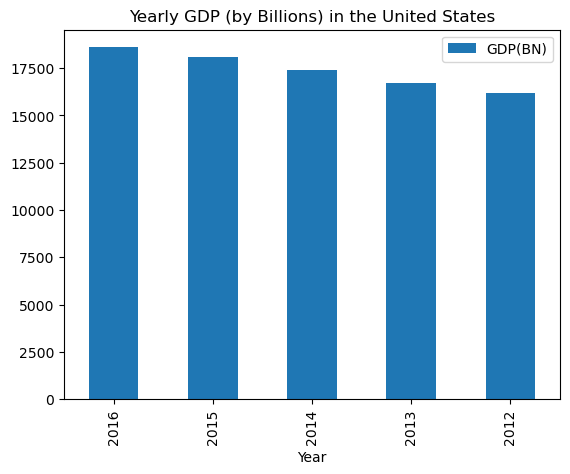

In [59]:
recent_us_gdp.plot(x = 'Year', y = 'GDP(BN)', kind = 'bar', title = 'Yearly GDP (by Billions) in the United States')

**Question 10** As a data scientist, you need to tell a story about your  work to the non-technical audiance, including your boss. Write a summary paragraph about your important work and some key findings from this case study. 

This shows a dabase of historical GDPs of different countries aroud the world. It doesnt have any missing data. The US GDP has steadily been increasing since 2012 as we can see from the graph, and other countries GDPS have also been increasing as we saw when we sorted by GDP.